# 03 Modelado

Se busca entrenar, evaluar y comparar distintos modelos supervisados para predecir churn, identificando cuál ofrece mejor capacidad predictiva y utilidad de negocio.

## 1. Importar librerias

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

## 2. Carga de datos

In [6]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [7]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


## 3. Modelos 

### 3.1 Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8356727976766699


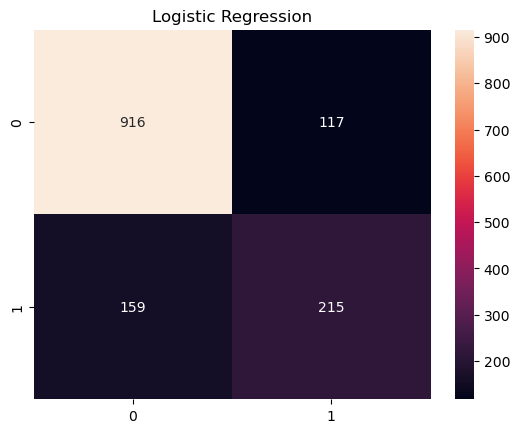

In [10]:
sns.heatmap(confusion_matrix(y_test,y_pred_lr),annot=True,fmt='d')
plt.title('Logistic Regression')
plt.show()

### 3.2 Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test,y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test,y_prob_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8172189407312691


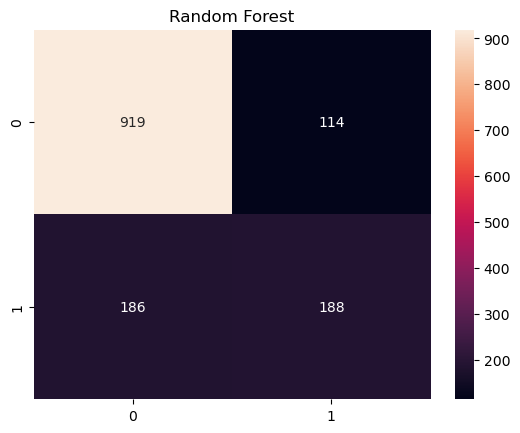

In [12]:
sns.heatmap(confusion_matrix(y_test,y_pred_rf),annot=True,fmt='d')
plt.title('Random Forest')
plt.show()

### 3.3 XGBoost

In [13]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train,y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test,y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test,y_prob_xgb))


              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

ROC-AUC: 0.8196701368217795


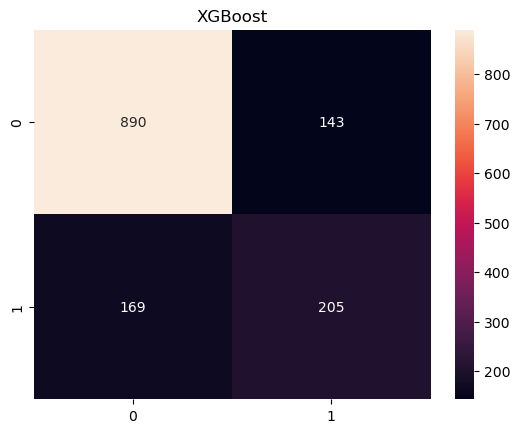

In [14]:
sns.heatmap(confusion_matrix(y_test,y_pred_xgb),annot=True,fmt='d')
plt.title('XGBoost')
plt.show()

## 4. Comparación de modelos

In [15]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest','XGBoost'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb)
    ],
    'ROC-AUC':[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_xgb)
    ]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.803838,0.835673
1,Random Forest,0.786780,0.817219
2,XGBoost,0.778252,0.819670


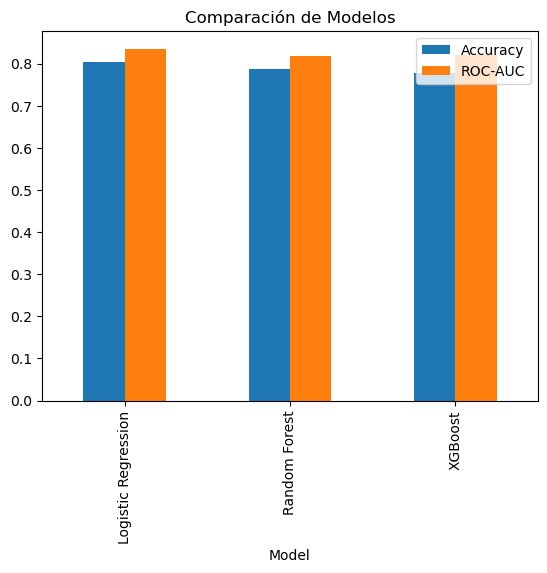

In [16]:
results.set_index('Model').plot(kind='bar')
plt.title('Comparación de Modelos')
plt.show()

## 5. Curvas ROC

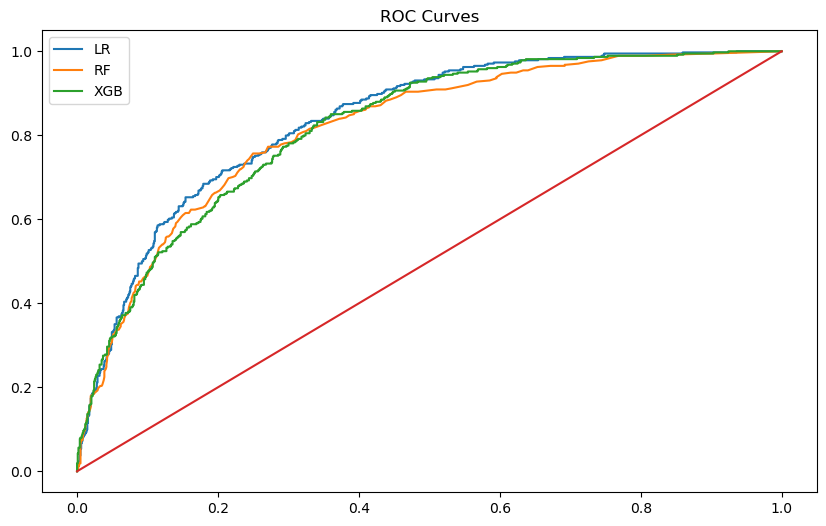

In [17]:
plt.figure(figsize=(10,6))

for probs,name in [
    (y_prob_lr,'LR'),
    (y_prob_rf,'RF'),
    (y_prob_xgb,'XGB')
]:
    fpr,tpr,_=roc_curve(y_test,probs)
    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1])
plt.legend()
plt.title('ROC Curves')
plt.show()